In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatwCDM
import camb
import sys
import os
import time

# Add the source directory to the Python path to use local development version
sys.path.insert(0, os.path.abspath('/datadec/cppm/boccard/excursion_set_functions/src'))

# Import from reference repository
from excursion_set_functions import analytical as f_an_py
from excursion_set_functions import integration
from excursion_set_functions import numerical
from excursion_set_functions.utilities import delta_NL_underdensity


# Import photo-z module from local development source
from excursion_set_functions.python.photo_z import compute_vsf_eulerian_with_photoz

import scipy.special as sp
from matplotlib import ticker

# Enable LaTeX for text rendering with better compatibility
plt.rcParams['text.usetex'] = True
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

/tmp/ipykernel_1909233/261298165.py:144: RuntimeWarning: invalid value encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]


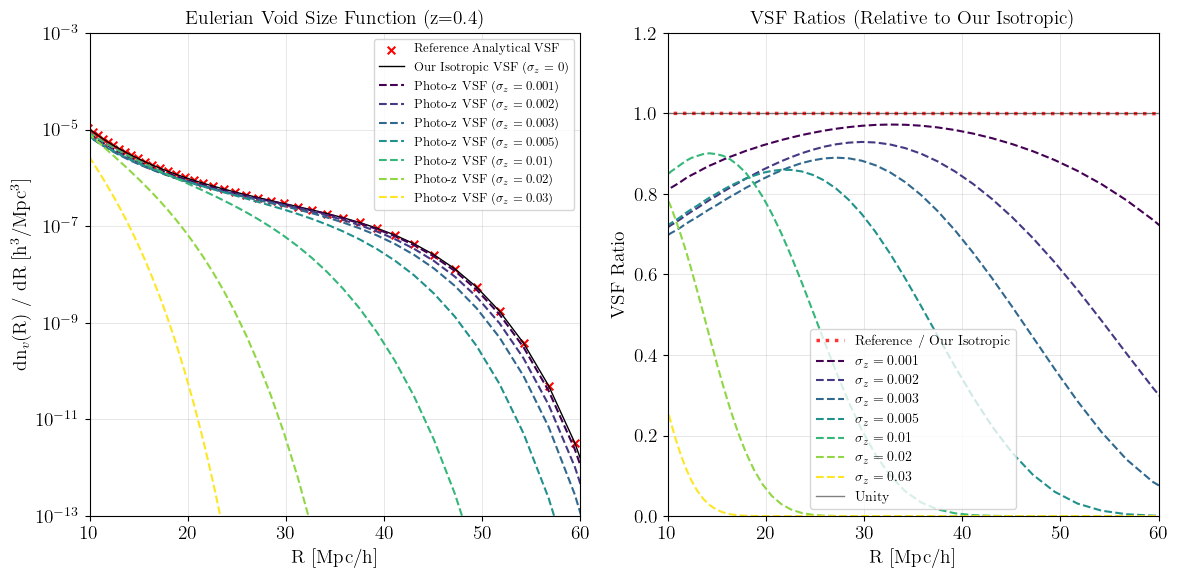

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
ax = axes[0]

# ===== COSMOLOGY AND POWER SPECTRUM =====
omega_m = 0.3
w = -1.0
redshift_min, redshift_max = 0.3, 0.5
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
z_mean = (redshift_min + redshift_max) / 2.0
a1, a2 = 0.0, 0.1
b1, b2 = 1, -0.7
gamma = 1
bias = 2
delta_v_lin = -0.8

# Compute power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo.H0.value, 
    ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
    omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
)
pars.InitPower.set_params(ns=0.965)
redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
pars.set_matter_power(redshifts=redshift, kmax=2.0)
results = camb.get_results(pars)
k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
Pk = np.mean(pk.T, axis=1)

# Reference computation
R = np.logspace(2, 0, 101)
s = integration.sigma2_TopHat(Pk, k, R)
s22 = integration.sigma2_2_TopHat_numdiff(Pk, k, R)
dsdR = integration.dSdR_TopHat(Pk, k, R)
DW = s22 / dsdR**2

alpha = a1 * abs(delta_v_lin) + a2
beta = b1 * abs(delta_v_lin) + b2

B = alpha * (1.0 + (beta / s)**gamma)
dB_ds = -alpha * beta**gamma * gamma * s**(-gamma - 1.0)

f_appr_R = f_an_py.f_S_MB_approx(s, DW, B, dB_ds) * np.abs(dsdR)
VSF_approx_L = 3.0 / (4.0 * np.pi * R**3) * f_appr_R

delta_v_NL = delta_NL_underdensity(delta_v_lin)
expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)
R_E = R * expansion_factor
VSF_approx_E = VSF_approx_L / expansion_factor

ax.scatter(R_E, VSF_approx_E, label='Reference Analytical VSF', 
        color='red', marker='x', s=30)



power_spectrum_cache = {}
R_E_iso, VSF_iso, s_iso = compute_vsf_eulerian_with_photoz(
    a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
    None, redshift_min, redshift_max, sigma_z=0.0,
    f_S_MB_approx_func=f_an_py.f_S_MB_approx,
    delta_NL_func=delta_NL_underdensity,
    power_spectrum_cache=power_spectrum_cache,
    verbose=True
)

ax.plot(R_E_iso, VSF_iso, label=r'Our Isotropic VSF ($\sigma_z=0$)', 
        color='black', linewidth=1)

# Photo-z cases
sigma_array = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03]
colors = plt.cm.viridis(np.linspace(0, 1, len(sigma_array)))

for idx, sigma_z in enumerate(sigma_array):
    
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        None, redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )
    
    label = fr'Photo-z VSF ($\sigma_z = {sigma_z}$)'
    ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])

# Format left plot
ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(10, 60)
ax.set_ylim(1e-13, 1e-3)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=9, loc='best')
ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)

# ===== RATIO PLOT =====
ax = axes[1]

# Interpolate to common R grid for fair comparison
from scipy.interpolate import interp1d

# Find common R range
R_common = np. linspace(
    max(R_E. min(), R_E_iso.min()),
    min(R_E.max(), R_E_iso.max()),
    200
)

# Interpolate both VSFs to common grid
VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                            bounds_error=False, fill_value=np.nan)
VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                            bounds_error=False, fill_value=np.nan)

VSF_ref_common = VSF_ref_interp(R_common)
VSF_iso_common = VSF_iso_interp(R_common)

# Compute ratio
valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
ratio_ref = np.full_like(R_common, np.nan)
ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]

# Plot reference/isotropic ratio
ax.plot(R_common, ratio_ref, 
        label=r'Reference / Our Isotropic', 
        color='red', linestyle=':', linewidth=2.5, alpha=0.8)

# Plot photo-z ratios
for idx, sigma_z in enumerate(sigma_array):
    R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        None, redshift_min, redshift_max, sigma_z=sigma_z,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=False
    )
    
    valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
    if np.any(valid):
        ratio = np.full_like(VSF_ph, np.nan)
        ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
        ax.plot(R_E_ph, ratio, label=fr'$\sigma_z={sigma_z}$', 
                linestyle='--', color=colors[idx])

ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'VSF Ratio', fontsize=14)
ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
ax.set_xlim(10, 60)
ax.set_ylim(0.0, 1.2)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1909233/4277345845.py:148: RuntimeWarning: invalid value encountered in divide
  ratio[valid] = VSF_ph[valid] / VSF_iso[valid]


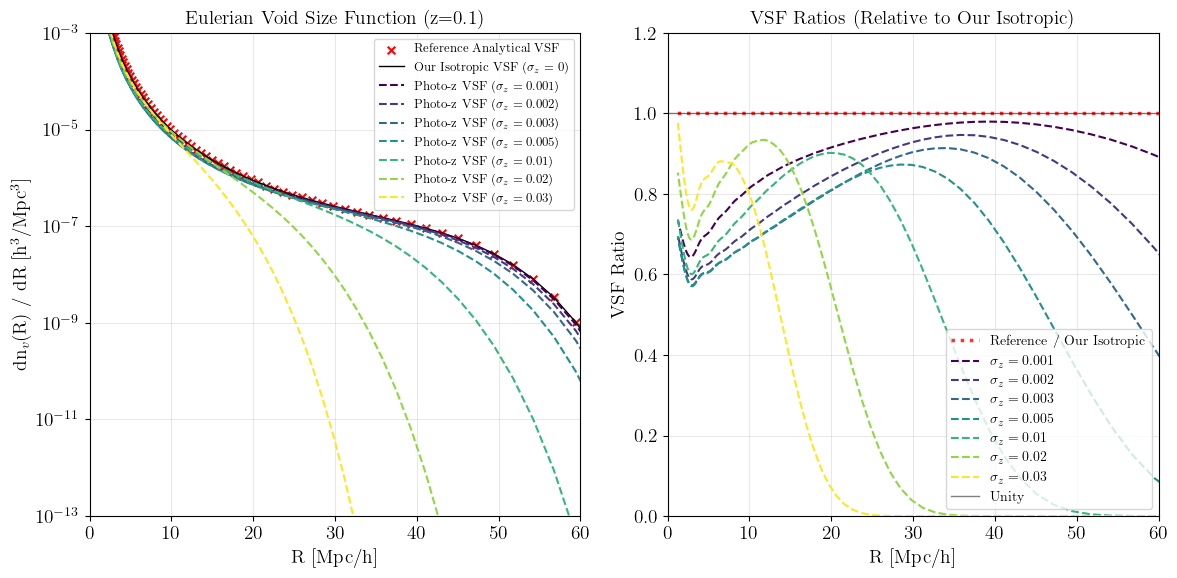

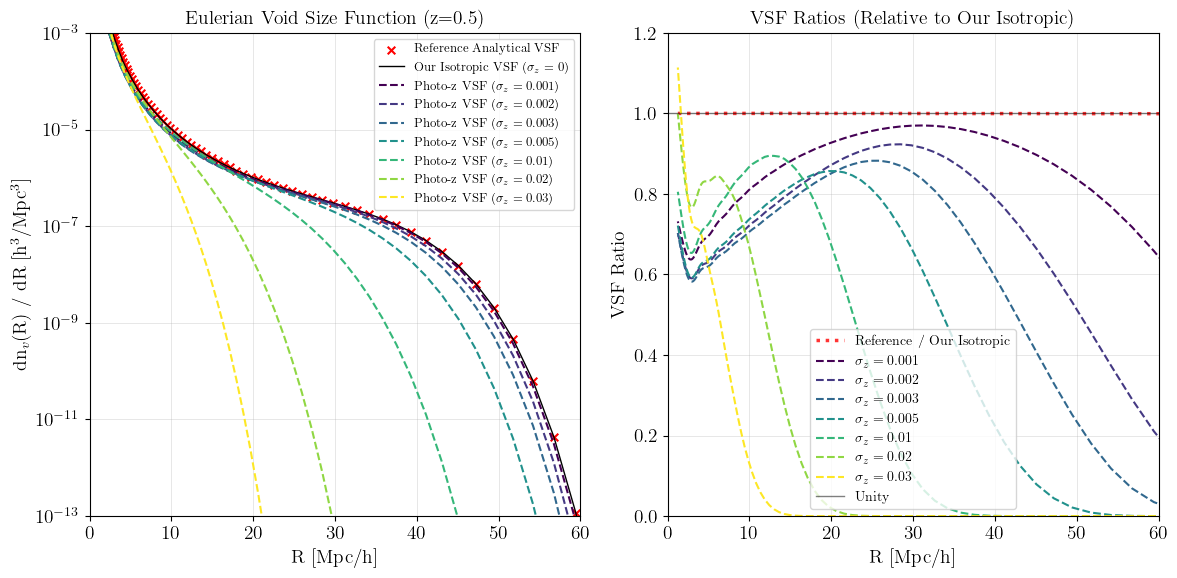

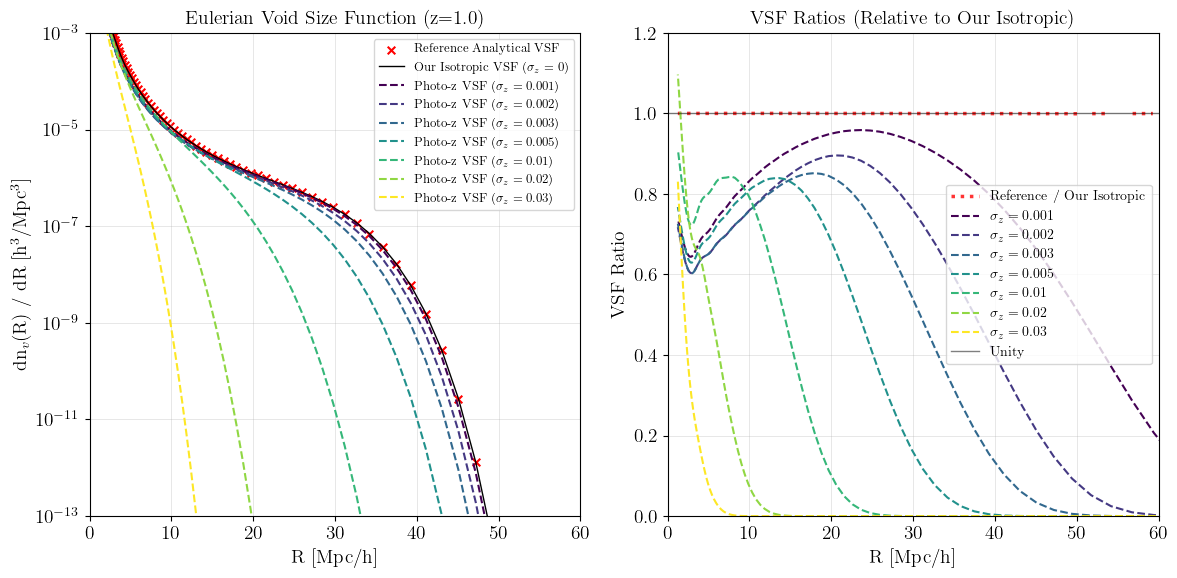

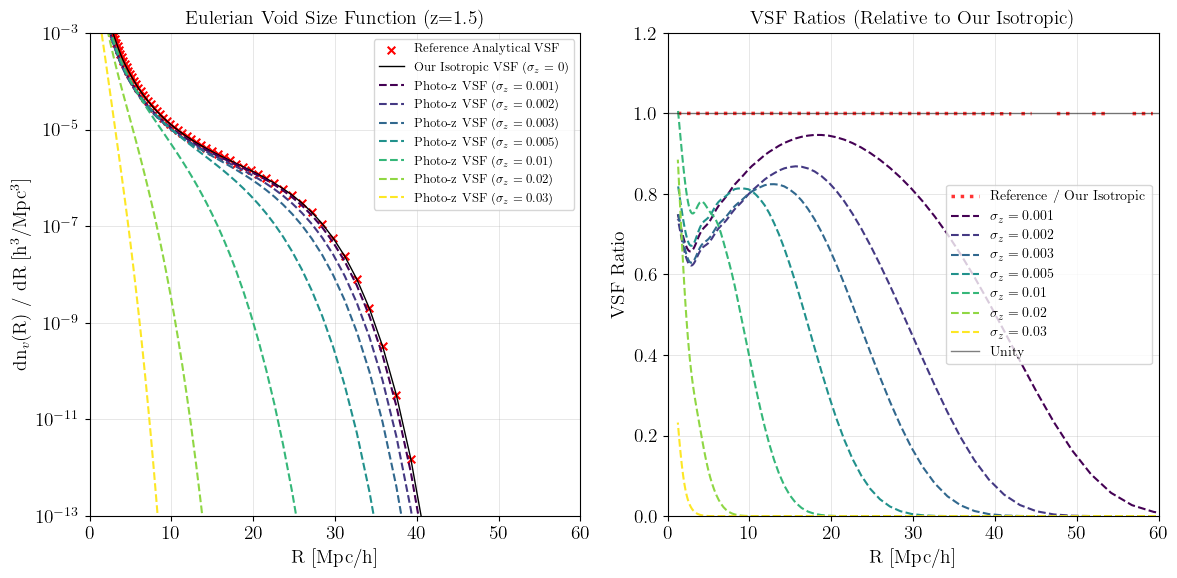

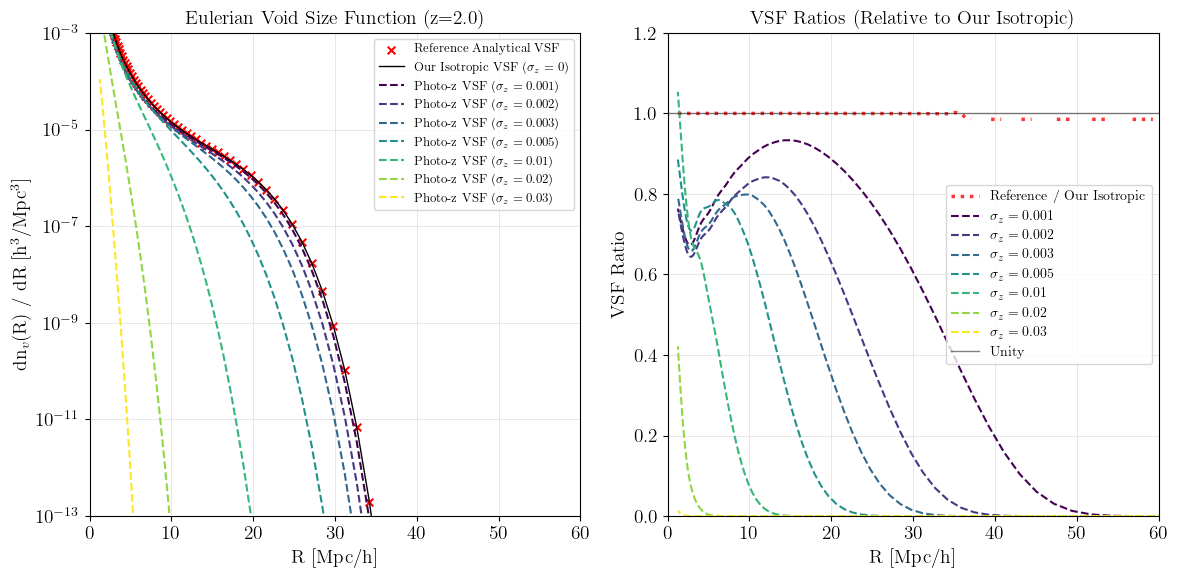

In [14]:
z_mean_list = [0.1, 0.5, 1., 1.5, 2.0]
for z_mean in z_mean_list:
    
    redshift_min = z_mean - 0.1
    redshift_max = z_mean + 0.1

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax = axes[0]

    # ===== COSMOLOGY AND POWER SPECTRUM =====
    omega_m = 0.3
    w = -1.0
    cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
    a1, a2 = 0.0, 0.1
    b1, b2 = 1, -0.7
    gamma = 1
    bias = 2

    # Compute power spectrum
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0=cosmo.H0.value, 
        ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
        omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
    )
    pars.InitPower.set_params(ns=0.965)
    redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
    pars.set_matter_power(redshifts=redshift, kmax=2.0)
    results = camb.get_results(pars)
    k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
    Pk = np.mean(pk.T, axis=1)

    # Reference computation
    R = np.logspace(2, 0, 101)
    s = integration.sigma2_TopHat(Pk, k, R)
    s22 = integration.sigma2_2_TopHat_numdiff(Pk, k, R)
    dsdR = integration.dSdR_TopHat(Pk, k, R)
    DW = s22 / dsdR**2

    delta_v_lin = -0.8
    alpha = a1 * abs(delta_v_lin) + a2
    beta = b1 * abs(delta_v_lin) + b2

    B = alpha * (1.0 + (beta / s)**gamma)
    dB_ds = -alpha * beta**gamma * gamma * s**(-gamma - 1.0)

    f_appr_R = f_an_py.f_S_MB_approx(s, DW, B, dB_ds) * np.abs(dsdR)
    VSF_approx_L = 3.0 / (4.0 * np.pi * R**3) * f_appr_R

    delta_v_NL = delta_NL_underdensity(delta_v_lin)
    expansion_factor = (1.0 + delta_v_NL)**(-1.0/3.0)
    R_E = R * expansion_factor
    VSF_approx_E = VSF_approx_L / expansion_factor

    ax.scatter(R_E, VSF_approx_E, label='Reference Analytical VSF', 
            color='red', marker='x', s=30)



    power_spectrum_cache = {}
    R_E_iso, VSF_iso, s_iso = compute_vsf_eulerian_with_photoz(
        a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
        None, redshift_min, redshift_max, sigma_z=0.0,
        f_S_MB_approx_func=f_an_py.f_S_MB_approx,
        delta_NL_func=delta_NL_underdensity,
        power_spectrum_cache=power_spectrum_cache,
        verbose=True
    )

    ax.plot(R_E_iso, VSF_iso, label=r'Our Isotropic VSF ($\sigma_z=0$)', 
            color='black', linewidth=1)

    # Photo-z cases
    sigma_array = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.03]
    colors = plt.cm.viridis(np.linspace(0, 1, len(sigma_array)))

    for idx, sigma_z in enumerate(sigma_array):
        
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            None, redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=True
        )
        
        label = fr'Photo-z VSF ($\sigma_z = {sigma_z}$)'
        ax.plot(R_E_ph, VSF_ph, label=label, linestyle='--', color=colors[idx])

    # Format left plot
    ax.set_yscale('log')
    ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
    ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
    ax.set_xlim(0, 60)
    ax.set_ylim(1e-13, 1e-3)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    ax.set_title(f'Eulerian Void Size Function (z={z_mean:.1f})', fontsize=14)

    # ===== RATIO PLOT =====
    ax = axes[1]

    # Interpolate to common R grid for fair comparison
    from scipy.interpolate import interp1d

    # Find common R range
    R_common = np. linspace(
        max(R_E. min(), R_E_iso.min()),
        min(R_E.max(), R_E_iso.max()),
        200
    )

    # Interpolate both VSFs to common grid
    VSF_ref_interp = interp1d(R_E, VSF_approx_E, kind='cubic', 
                                bounds_error=False, fill_value=np.nan)
    VSF_iso_interp = interp1d(R_E_iso, VSF_iso, kind='cubic',
                                bounds_error=False, fill_value=np.nan)

    VSF_ref_common = VSF_ref_interp(R_common)
    VSF_iso_common = VSF_iso_interp(R_common)

    # Compute ratio
    valid_ref = ~np.isnan(VSF_ref_common) & ~np.isnan(VSF_iso_common) & (VSF_iso_common > 0)
    ratio_ref = np.full_like(R_common, np.nan)
    ratio_ref[valid_ref] = VSF_ref_common[valid_ref] / VSF_iso_common[valid_ref]

    # Plot reference/isotropic ratio
    ax.plot(R_common, ratio_ref, 
            label=r'Reference / Our Isotropic', 
            color='red', linestyle=':', linewidth=2.5, alpha=0.8)

    # Plot photo-z ratios
    for idx, sigma_z in enumerate(sigma_array):
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            None, redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=False
        )
        
        valid = ~np.isnan(VSF_ph) & ~np.isnan(VSF_iso)
        if np.any(valid):
            ratio = np.full_like(VSF_ph, np.nan)
            ratio[valid] = VSF_ph[valid] / VSF_iso[valid]
            ax.plot(R_E_ph, ratio, label=fr'$\sigma_z={sigma_z}$', 
                    linestyle='--', color=colors[idx])

    ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
    ax.set_ylabel(r'VSF Ratio', fontsize=14)
    ax.axhline(1.0, color='black', linestyle='-', linewidth=1.0, alpha=0.5, label='Unity')
    ax.set_xlim(0, 60)
    ax.set_ylim(0.0, 1.2)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
    ax.set_title(r'VSF Ratios (Relative to Our Isotropic)', fontsize=14)

    plt.tight_layout()
    plt.show()


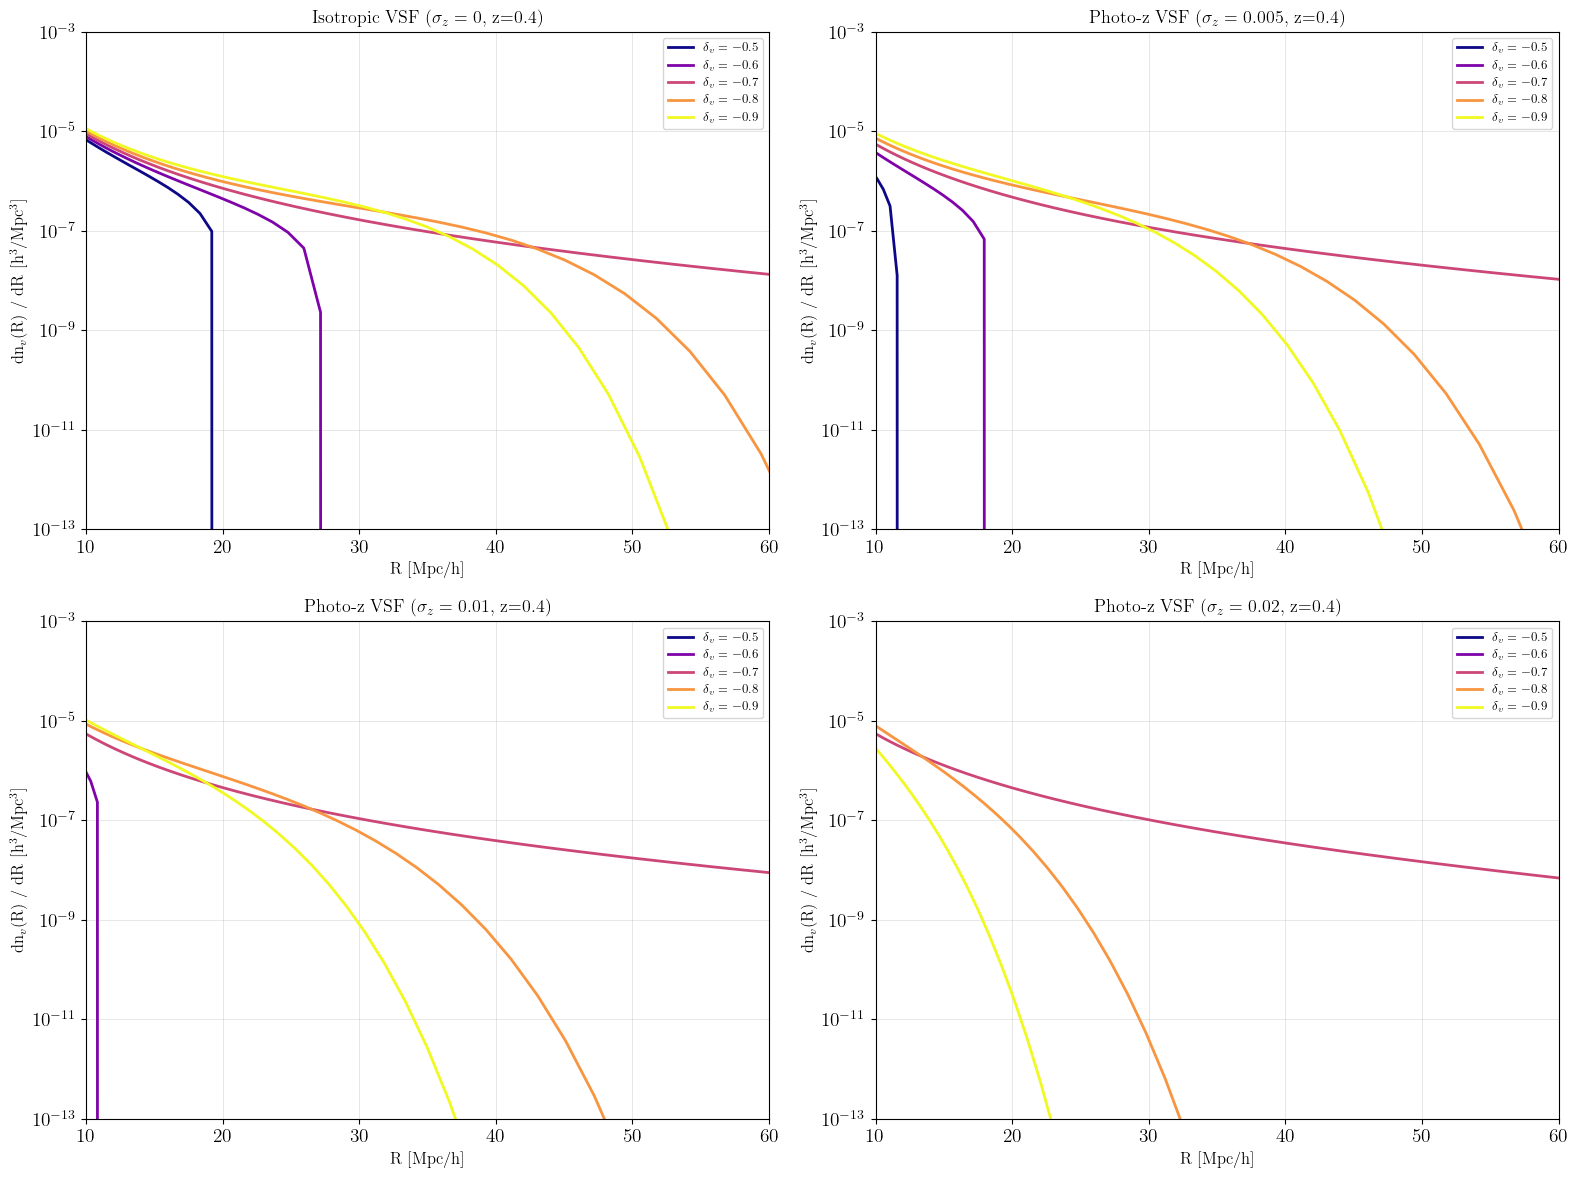

In [12]:
# Create 2x2 subplot grid for different sigma_z values
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Configuration
redshift_min, redshift_max = 0.3, 0.5
z_mean = (redshift_min + redshift_max) / 2.0
omega_m = 0.3
w = -1.0
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
a1, a2 = 0.0, 0.1
b1, b2 = 1, -0.7
gamma = 1
bias = 2

# Compute power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo.H0.value, 
    ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
    omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
)
pars.InitPower.set_params(ns=0.965)
redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
pars.set_matter_power(redshifts=redshift, kmax=2.0)
results = camb.get_results(pars)
k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
Pk = np.mean(pk.T, axis=1)

# Different sigma_z values for each subplot
sigma_z_values = [0.0, 0.005, 0.01, 0.02]

# Different delta_v_lin values to vary
delta_v_array = [-0.5, -0.6, -0.7, -0.8, -0.9]
colors_delta = plt.cm.plasma(np.linspace(0, 1, len(delta_v_array)))

for subplot_idx, sigma_z in enumerate(sigma_z_values):
    ax = axes[subplot_idx]
    power_spectrum_cache = {}
    
    for idx, delta_v_lin in enumerate(delta_v_array):
        
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            None, redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=False
        )
        
        label = fr'$\delta_v = {delta_v_lin}$'
        ax.plot(R_E_ph, VSF_ph, label=label, linestyle='-', 
                color=colors_delta[idx], linewidth=2)
    
    # Format subplot
    ax.set_yscale('log')
    ax.set_xlabel(r'R [Mpc/h]', fontsize=12)
    ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=12)
    ax.set_xlim(10, 60)
    ax.set_ylim(1e-13, 1e-3)
    ax.grid(visible=True, which='major', axis='both', 
            linestyle='-', linewidth=0.7, alpha=0.3)
    ax.legend(fontsize=9, loc='best')
    
    # Title with sigma_z value
    if sigma_z == 0.0:
        ax.set_title(fr'Isotropic VSF ($\sigma_z = 0$, z={z_mean:.1f})', fontsize=13)
    else:
        ax.set_title(fr'Photo-z VSF ($\sigma_z = {sigma_z}$, z={z_mean:.1f})', fontsize=13)

plt.tight_layout()
plt.show()


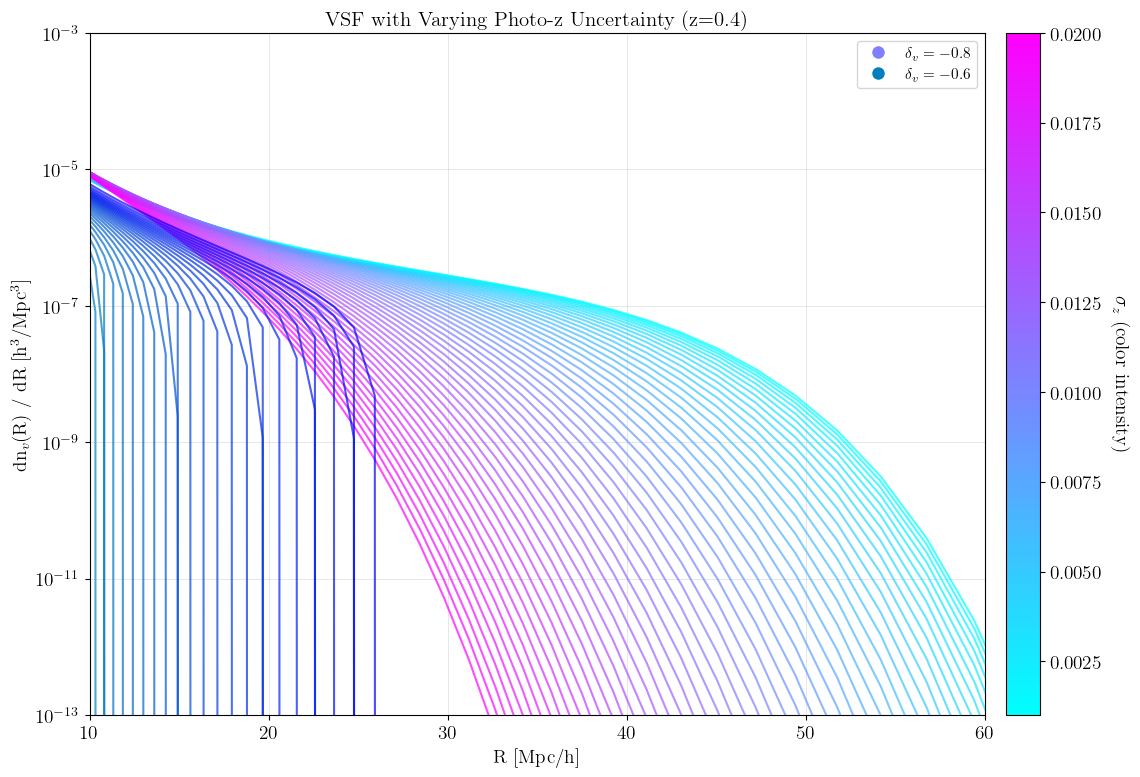

In [13]:
# Single plot with varying sigma_z and delta_v, using multiple colormaps
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Configuration
redshift_min, redshift_max = 0.3, 0.5
z_mean = (redshift_min + redshift_max) / 2.0
omega_m = 0.3
w = -1.0
cosmo = FlatwCDM(H0=71, Om0=omega_m, w0=w, Ob0=0.044)
a1, a2 = 0.0, 0.1
b1, b2 = 1, -0.7
gamma = 1
bias = 2

# Compute power spectrum
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo.H0.value, 
    ombh2=cosmo.Ob0 * (cosmo.H0.value / 100)**2, 
    omch2=(cosmo.Om0 - cosmo.Ob0) * (cosmo.H0.value / 100)**2
)
pars.InitPower.set_params(ns=0.965)
redshift = np.linspace(redshift_min, redshift_max, 10)[::-1]
pars.set_matter_power(redshifts=redshift, kmax=2.0)
results = camb.get_results(pars)
k, z_arr, pk = results.get_matter_power_spectrum(minkh=1.e-4, maxkh=2, npoints=1000)
Pk = np.mean(pk.T, axis=1)

# Parameter ranges
sigma_z_array = np.linspace(0.001, 0.02, 50)  # 50 values from 0.001 to 0.01 (linear scale)
delta_v_array = [-0.8, -0.6]  # Can add more values like [-0.6, -0.7, -0.8, -0.9]

# Different colormaps for different delta_v values
colormaps = [plt.cm.cool, plt.cm.winter]

power_spectrum_cache = {}

# Plot all combinations
for delta_idx, delta_v_lin in enumerate(delta_v_array):
    cmap = colormaps[delta_idx % len(colormaps)]
    
    for sigma_idx, sigma_z in enumerate(sigma_z_array):
        
        R_E_ph, VSF_ph, s_ph = compute_vsf_eulerian_with_photoz(
            a1, a2, b1, b2, gamma, delta_v_lin, omega_m, w, bias,
            None, redshift_min, redshift_max, sigma_z=sigma_z,
            f_S_MB_approx_func=f_an_py.f_S_MB_approx,
            delta_NL_func=delta_NL_underdensity,
            power_spectrum_cache=power_spectrum_cache,
            verbose=False
        )
        
        # Get color from colormap - use sigma_idx / (len(sigma_z_array) - 1) to get 0 to 1
        color = cmap(sigma_idx / (len(sigma_z_array) - 1))
        
        ax.plot(R_E_ph, VSF_ph, linestyle='-', 
                color=color, linewidth=1.5, alpha=0.7)

# Format plot
ax.set_yscale('log')
ax.set_xlabel(r'R [Mpc/h]', fontsize=14)
ax.set_ylabel(r'dn$_v$(R) / dR [h$^3$/Mpc$^3$]', fontsize=14)
ax.set_xlim(10, 60)
ax.set_ylim(1e-13, 1e-3)
ax.grid(visible=True, which='major', axis='both', 
        linestyle='-', linewidth=0.7, alpha=0.3)

# Add colorbars for each delta_v value
if len(delta_v_array) == 1:
    # Single colorbar - map to actual sigma_z values
    cmap = colormaps[0]
    norm_colorbar = plt.Normalize(vmin=sigma_z_array.min(), vmax=sigma_z_array.max())
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_colorbar)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    
    # Update colorbar label
    cbar.ax.set_ylabel(r'$\sigma_z$', fontsize=14, rotation=270, labelpad=20)
    
    # Add delta_v annotation
    ax.text(0.05, 0.95, fr'$\delta_v = {delta_v_array[0]}$', 
            transform=ax.transAxes, fontsize=13, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
else:
    # Multiple colorbars - create custom legend with colored patches
    from matplotlib.patches import Rectangle
    from matplotlib.lines import Line2D
    
    # Create legend showing colormap for each delta_v
    legend_elements = []
    for delta_idx, delta_v in enumerate(delta_v_array):
        cmap = colormaps[delta_idx % len(colormaps)]
        # Create a gradient patch for each delta_v
        legend_elements.append(Line2D([0], [0], marker='o', color='w',
                                     markerfacecolor=cmap(0.5), markersize=10,
                                     label=fr'$\delta_v = {delta_v}$'))
    
    ax.legend(handles=legend_elements, fontsize=11, loc='best')
    
    # Add a single colorbar with sigma_z scale (using first colormap as reference)
    norm_colorbar = plt.Normalize(vmin=sigma_z_array.min(), vmax=sigma_z_array.max())
    sm = plt.cm.ScalarMappable(cmap=colormaps[0], norm=norm_colorbar)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02)
    cbar.ax.set_ylabel(r'$\sigma_z$ (color intensity)', fontsize=14, rotation=270, labelpad=20)

ax.set_title(f'VSF with Varying Photo-z Uncertainty (z={z_mean:.1f})', fontsize=15)

plt.tight_layout()
plt.show()
